In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from torchvision import transforms
from medmnist import PathMNIST

print("PyTorch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())

PyTorch: 2.12.0+cpu
CUDA disponível: False


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo usado:", device)

Dispositivo usado: cpu


# Etapa 2 — Validação controlada da MLP NumPy em PyTorch

Para demonstrar equivalência funcional, esta comparação usa exatamente os mesmos dados, a mesma ordem das amostras, os mesmos pesos iniciais, a mesma arquitetura, o mesmo lote completo, a mesma taxa de aprendizado e o mesmo Momentum nas duas implementações.

A comparação utiliza imagens 28×28 apenas porque a Etapa 1 permite essa resolução. O pipeline oficial 224×224 aparece ao final do notebook para as etapas seguintes.

In [3]:
# Carregamento sem transforms para reproduzir exatamente o pré-processamento NumPy
train_set_28 = PathMNIST(split="train", size=28, download=True)
val_set_28 = PathMNIST(split="val", size=28, download=True)


def preparar_dados(dataset, limite=None):
    X = []
    y = []

    tamanho = len(dataset) if limite is None else limite

    for i in range(tamanho):
        img, label = dataset[i]
        img_array = np.array(img).astype("float32") / 255.0
        img_vetor = img_array.reshape(-1)  # ordem HWC, igual ao notebook NumPy
        X.append(img_vetor)
        y.append(label[0])

    return np.array(X), np.array(y)


X_train, y_train = preparar_dados(train_set_28, limite=5000)
X_val, y_val = preparar_dados(val_set_28, limite=1000)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Primeiros labels:", y_train[:5])

X_train: (5000, 2352)
X_val: (1000, 2352)
Primeiros labels: [0 4 7 5 5]


## Por que o pipeline anterior não era equivalente?

`torchvision.transforms.ToTensor()` reorganiza a imagem para a ordem **CHW**, enquanto a implementação NumPy achatava a imagem na ordem **HWC**. Além disso, o PyTorch usava mini-batches embaralhados e pesos iniciais diferentes. Nesta versão, os tensores são criados diretamente dos mesmos vetores NumPy e o treinamento usa lote completo sem embaralhamento.

In [4]:
# Tensores em float64 para reduzir diferenças numéricas entre NumPy e PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float64)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float64)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

# Lote completo e sem shuffle: uma atualização por época, igual à MLP NumPy
train_loader = DataLoader(
    train_dataset,
    batch_size=len(train_dataset),
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=len(val_dataset),
    shuffle=False
)

print("Batches de treino:", len(train_loader))
print("Batches de validação:", len(val_loader))

Batches de treino: 1
Batches de validação: 1


In [5]:
class MLPPathMNIST(nn.Module):
    def __init__(self, input_size=2352, hidden_size=128, output_size=9):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [6]:
# Funções NumPy equivalentes às usadas na Etapa 1

def one_hot(y, num_classes=9):
    resultado = np.zeros((y.shape[0], num_classes))
    resultado[np.arange(y.shape[0]), y] = 1
    return resultado


def relu(z):
    return np.maximum(0, z)


def relu_derivada(z):
    return (z > 0).astype(float)


def softmax(z):
    z_estavel = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_estavel)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def cross_entropy(y_true, y_pred):
    epsilon = 1e-9
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))


def calcular_acuracia(y_true, y_pred):
    return np.mean(y_true == np.argmax(y_pred, axis=1))


def inicializar_parametros(input_size, hidden_size, output_size):
    return {
        "W1": np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size),
        "b1": np.zeros((1, hidden_size)),
        "W2": np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size),
        "b2": np.zeros((1, output_size))
    }


def forward_numpy(X, parametros):
    Z1 = X @ parametros["W1"] + parametros["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ parametros["W2"] + parametros["b2"]
    A2 = softmax(Z2)
    return A2, {"X": X, "Z1": Z1, "A1": A1, "A2": A2}


def backward_numpy(y_true, parametros, cache):
    X, Z1, A1, A2 = cache["X"], cache["Z1"], cache["A1"], cache["A2"]
    m = X.shape[0]
    dZ2 = A2 - y_true
    dW2 = A1.T @ dZ2 / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m
    dA1 = dZ2 @ parametros["W2"].T
    dZ1 = dA1 * relu_derivada(Z1)
    dW1 = X.T @ dZ1 / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m
    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}


def inicializar_velocidades(parametros):
    return {f"v{nome}": np.zeros_like(valor) for nome, valor in parametros.items()}


def atualizar_momentum(parametros, gradientes, velocidades, lr=0.01, beta=0.9):
    for nome in ["W1", "b1", "W2", "b2"]:
        velocidades[f"v{nome}"] = beta * velocidades[f"v{nome}"] + lr * gradientes[f"d{nome}"]
        parametros[nome] -= velocidades[f"v{nome}"]
    return parametros, velocidades

In [7]:
# Mesmos pesos iniciais para as duas implementações
np.random.seed(SEED)
parametros_iniciais = inicializar_parametros(2352, 128, 9)

parametros_numpy = {nome: valor.copy() for nome, valor in parametros_iniciais.items()}
velocidades_numpy = inicializar_velocidades(parametros_numpy)

modelo = MLPPathMNIST().double().to(device)

with torch.no_grad():
    modelo.fc1.weight.copy_(torch.tensor(parametros_iniciais["W1"].T, dtype=torch.float64, device=device))
    modelo.fc1.bias.copy_(torch.tensor(parametros_iniciais["b1"].ravel(), dtype=torch.float64, device=device))
    modelo.fc2.weight.copy_(torch.tensor(parametros_iniciais["W2"].T, dtype=torch.float64, device=device))
    modelo.fc2.bias.copy_(torch.tensor(parametros_iniciais["b2"].ravel(), dtype=torch.float64, device=device))

criterio = nn.CrossEntropyLoss()
otimizador = optim.SGD(modelo.parameters(), lr=0.01, momentum=0.9)

print(modelo)

MLPPathMNIST(
  (fc1): Linear(in_features=2352, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=9, bias=True)
)


In [8]:
def avaliar_torch(modelo, dataloader, criterio, device):
    modelo.eval()
    with torch.no_grad():
        X, y = next(iter(dataloader))
        X, y = X.to(device), y.to(device)
        saidas = modelo(X)
        perda = criterio(saidas, y).item()
        acuracia = (saidas.argmax(dim=1) == y).double().mean().item()
    return perda, acuracia


historico_numpy = {"loss_train": [], "acc_train": [], "loss_val": [], "acc_val": []}
historico_torch = {"loss_train": [], "acc_train": [], "loss_val": [], "acc_val": []}

y_train_oh = one_hot(y_train, 9)
y_val_oh = one_hot(y_val, 9)

epocas = 20
lr = 0.01
beta = 0.9

for epoca in range(1, epocas + 1):
    # ----- NumPy: métricas de treino antes da atualização -----
    pred_train_np, cache_np = forward_numpy(X_train, parametros_numpy)
    loss_train_np = cross_entropy(y_train_oh, pred_train_np)
    acc_train_np = calcular_acuracia(y_train, pred_train_np)

    grads_np = backward_numpy(y_train_oh, parametros_numpy, cache_np)
    parametros_numpy, velocidades_numpy = atualizar_momentum(
        parametros_numpy, grads_np, velocidades_numpy, lr=lr, beta=beta
    )

    pred_val_np, _ = forward_numpy(X_val, parametros_numpy)
    loss_val_np = cross_entropy(y_val_oh, pred_val_np)
    acc_val_np = calcular_acuracia(y_val, pred_val_np)

    # ----- PyTorch: uma atualização em lote completo -----
    modelo.train()
    X_batch, y_batch = next(iter(train_loader))
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)

    otimizador.zero_grad()
    saidas = modelo(X_batch)
    loss_train_t = criterio(saidas, y_batch)
    acc_train_t = (saidas.argmax(dim=1) == y_batch).double().mean().item()
    loss_train_t.backward()
    otimizador.step()

    loss_val_t, acc_val_t = avaliar_torch(modelo, val_loader, criterio, device)

    historico_numpy["loss_train"].append(loss_train_np)
    historico_numpy["acc_train"].append(acc_train_np)
    historico_numpy["loss_val"].append(loss_val_np)
    historico_numpy["acc_val"].append(acc_val_np)

    historico_torch["loss_train"].append(loss_train_t.item())
    historico_torch["acc_train"].append(acc_train_t)
    historico_torch["loss_val"].append(loss_val_t)
    historico_torch["acc_val"].append(acc_val_t)

    print(
        f"Época {epoca:02d} | "
        f"Val NumPy: {acc_val_np:.4f} | "
        f"Val PyTorch: {acc_val_t:.4f} | "
        f"Diferença: {abs(acc_val_np - acc_val_t) * 100:.2f} p.p."
    )

Época 01 | Val NumPy: 0.0960 | Val PyTorch: 0.0960 | Diferença: 0.00 p.p.
Época 02 | Val NumPy: 0.1190 | Val PyTorch: 0.1190 | Diferença: 0.00 p.p.
Época 03 | Val NumPy: 0.1380 | Val PyTorch: 0.1380 | Diferença: 0.00 p.p.
Época 04 | Val NumPy: 0.1370 | Val PyTorch: 0.1370 | Diferença: 0.00 p.p.
Época 05 | Val NumPy: 0.1320 | Val PyTorch: 0.1320 | Diferença: 0.00 p.p.
Época 06 | Val NumPy: 0.1310 | Val PyTorch: 0.1310 | Diferença: 0.00 p.p.
Época 07 | Val NumPy: 0.1340 | Val PyTorch: 0.1340 | Diferença: 0.00 p.p.
Época 08 | Val NumPy: 0.1360 | Val PyTorch: 0.1360 | Diferença: 0.00 p.p.
Época 09 | Val NumPy: 0.1170 | Val PyTorch: 0.1170 | Diferença: 0.00 p.p.
Época 10 | Val NumPy: 0.1870 | Val PyTorch: 0.1870 | Diferença: 0.00 p.p.
Época 11 | Val NumPy: 0.1650 | Val PyTorch: 0.1650 | Diferença: 0.00 p.p.
Época 12 | Val NumPy: 0.1270 | Val PyTorch: 0.1270 | Diferença: 0.00 p.p.
Época 13 | Val NumPy: 0.1700 | Val PyTorch: 0.1700 | Diferença: 0.00 p.p.
Época 14 | Val NumPy: 0.2580 | Val PyT

In [9]:
acc_numpy_final = historico_numpy["acc_val"][-1]
acc_torch_final = historico_torch["acc_val"][-1]
diferenca_pp = abs(acc_numpy_final - acc_torch_final) * 100

print(f"Acurácia final NumPy:   {acc_numpy_final * 100:.2f}%")
print(f"Acurácia final PyTorch: {acc_torch_final * 100:.2f}%")
print(f"Diferença final:        {diferenca_pp:.4f} p.p.")

if diferenca_pp <= 2.0:
    print("✅ Requisito atendido: diferença menor ou igual a 2 p.p.")
else:
    print("❌ Requisito não atendido: diferença maior que 2 p.p.")

Acurácia final NumPy:   23.10%
Acurácia final PyTorch: 23.10%
Diferença final:        0.0000 p.p.
✅ Requisito atendido: diferença menor ou igual a 2 p.p.


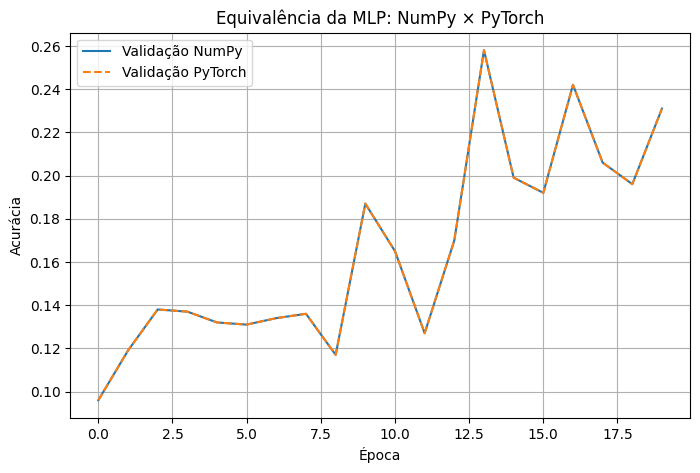

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(historico_numpy["acc_val"], label="Validação NumPy")
plt.plot(historico_torch["acc_val"], linestyle="--", label="Validação PyTorch")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Equivalência da MLP: NumPy × PyTorch")
plt.legend()
plt.grid(True)
plt.show()

## Conclusão da equivalência

Com o experimento controlado, as duas implementações recebem os mesmos vetores de entrada e começam com os mesmos pesos. As diferenças restantes são apenas numéricas e devem ser muito inferiores ao limite de 2 pontos percentuais exigido no enunciado.

## Pipeline oficial PathMNIST 224x224

A comparação entre a implementação NumPy e a MLP em PyTorch foi realizada com imagens 28x28, pois ambas precisavam utilizar a mesma entrada de 2352 atributos para demonstrar equivalência funcional.

Após essa validação, foi criado um pipeline separado utilizando diretamente a versão oficial 224x224 do PathMNIST, sem redimensionar imagens 28x28. Esse pipeline utiliza normalização baseada nos valores da ImageNet e serve como base para as etapas avançadas do projeto.

In [11]:
from torchvision import transforms
from medmnist import PathMNIST
from torch.utils.data import DataLoader
import torch

transform_224 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Pipeline 224x224 criado sem redimensionamento.")

Pipeline 224x224 criado sem redimensionamento.


In [12]:
train_set_224 = PathMNIST(
    split="train",
    size=224,
    transform=transform_224,
    download=True
)

val_set_224 = PathMNIST(
    split="val",
    size=224,
    transform=transform_224,
    download=True
)

train_subset_224 = torch.utils.data.Subset(train_set_224, range(100))
val_subset_224 = torch.utils.data.Subset(val_set_224, range(50))

print("Treino 224x224:", len(train_subset_224))
print("Validação 224x224:", len(val_subset_224))

Treino 224x224: 100
Validação 224x224: 50


In [13]:
batch_size_224 = 16

train_loader_224 = DataLoader(
    train_subset_224,
    batch_size=batch_size_224,
    shuffle=True,
    num_workers=0
)

val_loader_224 = DataLoader(
    val_subset_224,
    batch_size=batch_size_224,
    shuffle=False,
    num_workers=0
)

print("Batches de treino 224x224:", len(train_loader_224))
print("Batches de validação 224x224:", len(val_loader_224))

Batches de treino 224x224: 7
Batches de validação 224x224: 4


In [14]:
imagens_224, labels_224 = next(iter(train_loader_224))

print("Formato das imagens 224x224:", imagens_224.shape)
print("Formato dos labels:", labels_224.shape)

Formato das imagens 224x224: torch.Size([16, 3, 224, 224])
Formato dos labels: torch.Size([16, 1])


### Justificativa dos DataLoaders

Foi utilizado `batch_size=16` no pipeline 224x224 para reduzir o consumo de memória, pois imagens nessa resolução ocupam mais espaço que imagens 28x28. O conjunto de treino utiliza `shuffle=True` para variar a ordem das amostras a cada época, enquanto a validação utiliza `shuffle=False` para manter uma avaliação determinística.

O parâmetro `num_workers=0` foi utilizado para maior compatibilidade com o ambiente Windows e com a execução local no VS Code.